[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/danpele/Advanced-Time-Series/blob/main/notebooks/EN/chapter0_lecture_notebook.ipynb)

# Advanced Time Series Analysis and Forecasting — Chapter 0: Refresher and inference for dependent data

*Lecture notebook. Daniel Traian Pele, Bucharest University of Economic Studies.*

- Dependence in our data: Romanian HICP inflation and GDP growth (Eurostat), EUR/RON (BNR), S&P 500 and BET (EODHD).
- The long-run variance and the size of the naive t-test; HAC estimators (Newey–West 1987, Andrews 1991), fixed-b critical values (Kiefer–Vogelsang 2005), the LLSW (2018) recommendations.
- A Monte Carlo of size; block bootstraps (Künsch 1989, Politis–Romano 1994) with the Politis–White block length.
- Overlapping observations (term spread and growth, FRED); data snooping and White's (2000) Reality Check on the BET.
- AI mini-case: has Romanian inflation averaged the 2.5% target since 2013?
- Everything is computed with numpy/scipy; the seed is 2026.

> **Working in Google Colab? Save your own copy first.**
> The Colab link opens a temporary copy: when you close the tab or the session times out, your changes are lost.
> Use **File → Save a copy in Drive** (it goes to the *Colab Notebooks* folder of your ASE Google Drive) and work in that copy.
> For the team project, **File → Save a copy in GitHub** puts the notebook directly in your team's repository.
> Files you create while the notebook runs (CSV, charts) are also temporary: set `SAVE_TO_DRIVE = True` in the next cell to keep them.

In [1]:
# Optional (Colab only): keep the files you create in Google Drive
SAVE_TO_DRIVE = False   # set to True, run this cell and allow access to your Drive

import os
OUT_DIR = '.'
if SAVE_TO_DRIVE:
    from google.colab import drive
    drive.mount('/content/drive')
    OUT_DIR = '/content/drive/MyDrive/ATS/Chapter_0'
    os.makedirs(OUT_DIR, exist_ok=True)
print('Save your outputs to:', os.path.abspath(OUT_DIR))


Save your outputs to: /Users/danpele/Documents/Teaching/ATS - Modelarea avansata a seriilor de timp/repo/notebooks/EN


In [2]:
import os
import re
import json
import urllib.request
import numpy as np
import pandas as pd
import matplotlib as mpl
import matplotlib.pyplot as plt
from matplotlib.colors import to_rgb
from scipy import optimize
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

## Chart style

- Transparent background, legend below the plot, course palette.

In [3]:
# Palette (RGB values of latex/preamble.tex)
MainBlue = '#1A3A6E'
IDAred = '#CD0000'
Forest = '#2E7D32'
Amber = '#B5853F'
Orange = '#E67E22'
Purple = '#8E44AD'
Teal = '#17A2B8'
Crimson = '#DC3545'
DarkText = '#1F2A44'          # text, axes and ticks (dark navy, not grey)

PALETTE = [MainBlue, IDAred, Forest, Amber, Purple, Orange, Teal, Crimson]
# fixed colours for the series used in several chapters
COL = {'sp500': MainBlue, 'bet': IDAred, 'bettr': Orange, 'dax': Teal, 'btc': Amber, 'eth': Crimson,
       'eurron': Forest, 'gold': Purple, 'vix': Crimson, 'stoxx50': Forest, 'ndx': Teal}


def apply():
    """Set the course style for matplotlib."""
    rc = plt.rcParams
    rc['figure.facecolor'] = 'none'
    rc['axes.facecolor'] = 'none'
    rc['savefig.facecolor'] = 'none'
    rc['savefig.transparent'] = True
    rc['axes.grid'] = False
    rc['font.family'] = 'sans-serif'
    rc['font.sans-serif'] = ['Helvetica', 'Arial', 'DejaVu Sans']
    # font sizes for slides (charts are 9-11 inches wide and shown at 8-14 cm)
    rc['font.size'] = 12
    rc['axes.labelsize'] = 13
    rc['axes.titlesize'] = 13
    rc['xtick.labelsize'] = 11.5
    rc['ytick.labelsize'] = 11.5
    rc['legend.fontsize'] = 11
    rc['axes.spines.top'] = False
    rc['axes.spines.right'] = False
    rc['axes.linewidth'] = 0.6
    rc['lines.linewidth'] = 1.4
    rc['legend.facecolor'] = 'none'
    rc['legend.framealpha'] = 0
    rc['legend.frameon'] = False
    for k in ('text.color', 'axes.labelcolor', 'axes.edgecolor', 'xtick.color', 'ytick.color', 'axes.titlecolor'):
        rc[k] = DarkText
    rc['axes.prop_cycle'] = mpl.cycler(color=PALETTE)


def legend_outside_bottom(ax, ncol=2, y=-0.22, **kw):
    """Place the legend outside the plot, bottom centre (for a figure with several axes, pass the last one
    or use fig.legend with the same arguments)."""
    return ax.legend(loc='upper center', bbox_to_anchor=(0.5, y), ncol=ncol, frameon=False, **kw)


def fig_legend_bottom(fig, handles=None, labels=None, ncol=3, y=-0.02):
    """One legend for a whole figure (several panels), below the panels."""
    if handles is None:
        handles, labels = [], []
        for ax in fig.axes:
            for h, l in zip(*ax.get_legend_handles_labels()):
                if l not in labels and not l.startswith('_'):
                    handles.append(h)
                    labels.append(l)
    return fig.legend(handles, labels, loc='upper center', bbox_to_anchor=(0.5, y), ncol=ncol, frameon=False)


def _is_grey(c, tol=0.06):
    try:
        r, g, b = to_rgb(c)
    except ValueError:
        return False
    return max(r, g, b) - min(r, g, b) < tol and 0.25 < (r + g + b) / 3 < 0.95


def check_no_grey(fig):
    """House rule: no grey series and no grey text. Raises ValueError listing the offending elements."""
    bad = []
    for ax in fig.axes:
        for ln in ax.get_lines():
            if not ln.get_label().startswith('_') and _is_grey(ln.get_color()):
                bad.append(f'line {ln.get_label()!r}')
        for coll in ax.collections:
            fc = coll.get_facecolor()
            if len(fc) and coll.get_label() and not coll.get_label().startswith('_') and _is_grey(fc[0][:3]):
                bad.append(f'series {coll.get_label()!r}')
        for t in ax.texts + [ax.title, ax.xaxis.label, ax.yaxis.label]:
            if t.get_text() and _is_grey(t.get_color()):
                bad.append(f'text {t.get_text()[:30]!r}')
    if bad:
        raise ValueError('grey elements: ' + ', '.join(bad))


def save_fig(name, out_dir=None, show=True):
    """Save the figure as transparent PDF and PNG (OUT_DIR if defined, else the current folder), then show it."""
    d = out_dir or globals().get('OUT_DIR', '.')
    plt.savefig(os.path.join(d, f'{name}.pdf'), bbox_inches='tight', transparent=True)
    plt.savefig(os.path.join(d, f'{name}.png'), bbox_inches='tight', transparent=True, dpi=180)
    if show:
        plt.show()
    plt.close()


apply()
# the chapter scripts call the style as st.<name> (import ats_style as st): the same names here
import types
st = types.SimpleNamespace(COL=COL, PALETTE=PALETTE, MainBlue=MainBlue, IDAred=IDAred, Forest=Forest, Amber=Amber,
                           Orange=Orange, Purple=Purple, Teal=Teal, Crimson=Crimson, DarkText=DarkText, apply=apply, legend_outside_bottom=legend_outside_bottom,
                           fig_legend_bottom=fig_legend_bottom, save_fig=save_fig, check_no_grey=check_no_grey)

## Data

- Daily market data from EODHD, saved in `data/market` of the ATS repository; EUR/RON is the official BNR reference rate.
- Macroeconomic series: FRED (St. Louis Fed), Eurostat and the classic data sets of statsmodels.
- Returns in %: $r_t = 100(\ln P_t - \ln P_{t-1})$; each series on its own calendar.

In [4]:
REPO_RAW = 'https://raw.githubusercontent.com/danpele/Advanced-Time-Series/main/data/market/'
# local copy of the course data, if the notebook runs inside the repository
MARKET_DIR = next((os.path.join(d, 'data', 'market') for d in ('.', '..', '../..', '../../..')
                   if os.path.isdir(os.path.join(d, 'data', 'market'))), '')
END = '2026-09-18'          # last day of the saved data

# name -> (symbol, label, group, field, default start)
SERIES = {
    # equity indices
    'sp500':    ('GSPC.INDX',     'S&P 500',               'Equity', 'close', '2000-01-01'),
    'ndx':      ('NDX.INDX',      'Nasdaq 100',            'Equity', 'close', '2000-01-01'),
    'dax':      ('GDAXI.INDX',    'DAX',                   'Equity', 'close', '2000-01-01'),
    'stoxx50':  ('STOXX50E.INDX', 'Euro Stoxx 50',         'Equity', 'close', '2000-01-01'),
    'nikkei':   ('N225.INDX',     'Nikkei 225',            'Equity', 'close', '2000-01-01'),
    'bet':      ('BET',           'BET',                   'Equity', 'close', '2000-01-01'),
    'bettr':    ('BETTR.INDX',    'BET-TR',                'Equity', 'close', '2014-09-23'),
    'betxt':    ('BETXT.INDX',    'BET-XT',                'Equity', 'close', '2011-08-12'),
    'betfi':    ('BETFI.INDX',    'BET-FI',                'Equity', 'close', '2012-01-25'),
    'wig20':    ('WIG20.INDX',    'WIG20',                 'Equity', 'close', '2000-01-01'),
    'bux':      ('BUX.INDX',      'BUX',                   'Equity', 'close', '2000-01-01'),
    'px':       ('PX.INDX',       'PX',                    'Equity', 'close', '2000-01-01'),
    'vix':      ('VIX.INDX',      'VIX',                   'Volatility', 'close', '2000-01-01'),
    # ETFs (adjusted close)
    'spy':      ('SPY.US',        'SPY',                   'ETF', 'adjusted_close', '2000-01-01'),
    'tlt':      ('TLT.US',        'TLT (US Treasuries 20y+)', 'ETF', 'adjusted_close', '2002-07-30'),
    'gld':      ('GLD.US',        'GLD (gold ETF)',        'ETF', 'adjusted_close', '2004-11-18'),
    'tvbetetf': ('TVBETETF.RO',   'TVBETETF',              'ETF', 'adjusted_close', '2015-06-12'),
    # Bucharest Stock Exchange (adjusted close)
    'tlv':      ('TLV.RO',        'Banca Transilvania',    'Stock', 'adjusted_close', '2000-01-01'),
    'snp':      ('SNP.RO',        'OMV Petrom',            'Stock', 'adjusted_close', '2001-09-04'),
    'brd':      ('BRD.RO',        'BRD',                   'Stock', 'adjusted_close', '2001-01-16'),
    'tgn':      ('TGN.RO',        'Transgaz',              'Stock', 'adjusted_close', '2008-01-25'),
    'sng':      ('SNG.RO',        'Romgaz',                'Stock', 'adjusted_close', '2013-11-12'),
    'snn':      ('SNN.RO',        'Nuclearelectrica',      'Stock', 'adjusted_close', '2013-11-04'),
    'h2o':      ('H2O.RO',        'Hidroelectrica',        'Stock', 'adjusted_close', '2023-07-12'),
    # US stocks (adjusted close)
    'aapl':     ('AAPL.US',       'Apple',                 'Stock', 'adjusted_close', '2000-01-01'),
    'msft':     ('MSFT.US',       'Microsoft',             'Stock', 'adjusted_close', '2000-01-01'),
    'nvda':     ('NVDA.US',       'NVIDIA',                'Stock', 'adjusted_close', '2000-01-01'),
    'jpm':      ('JPM.US',        'JPMorgan Chase',        'Stock', 'adjusted_close', '2000-01-01'),
    # crypto (close, 7 days a week)
    'btc':      ('BTC-USD.CC',    'Bitcoin',               'Crypto', 'close', '2014-09-17'),
    'eth':      ('ETH-USD.CC',    'Ethereum',              'Crypto', 'close', '2015-08-07'),
    'sol':      ('SOL-USD.CC',    'Solana',                'Crypto', 'close', '2020-04-11'),
    'usdt':     ('USDT-USD.CC',   'Tether (USDT)',         'Crypto', 'close', '2015-02-26'),
    # FX and commodities
    'eurron':   ('REF:EUR',       'EUR/RON (BNR reference)', 'FX', 'close', '2005-07-01'),
    'usdron':   ('REF:USD',       'USD/RON (BNR reference)', 'FX', 'close', '2005-07-01'),
    'eurron_eodhd': ('EURRON.FOREX', 'EUR/RON (EODHD)',    'FX', 'close', '2005-07-01'),
    'eurusd':   ('EURUSD.FOREX',  'EUR/USD',               'FX', 'close', '2002-05-06'),
    'gold':     ('XAUUSD.FOREX',  'Gold (XAU/USD)',        'Commodity', 'close', '2000-01-01'),
    # government bond yields (close, % p.a.)
    'us10y':    ('US10Y.GBOND',   'US 10Y yield',          'Yield', 'close', '2000-01-01'),
    'de10y':    ('DE10Y.GBOND',   'Germany 10Y yield',     'Yield', 'close', '2007-03-28'),
    'ro10y':    ('RO10Y.GBOND',   'Romania 10Y yield',     'Yield', 'close', '2007-08-17'),
}
LABELS = {k: v[1] for k, v in SERIES.items()}
_CACHE = {}


def read_market(symbol):
    """Daily table of one symbol: local copy of the course data, otherwise the ATS repository on GitHub."""
    fname = f'{symbol}.csv'
    path = os.path.join(MARKET_DIR, fname) if MARKET_DIR else ''
    src = path if path and os.path.exists(path) else REPO_RAW + fname
    return pd.read_csv(src, index_col='date', parse_dates=True).sort_index()


def read_reference_rate(currency='EUR', start='2005-07-01', end=END):
    """Official BNR reference rate (RON per unit of currency), from the public yearly XML archives."""
    key = (currency, start, end)
    if key in _CACHE:
        return _CACHE[key]
    rows = []
    for y in range(max(int(start[:4]), 2005), int(end[:4]) + 1):
        url = f'https://curs.bnr.ro/files/xml/years/nbrfxrates{y}.xml'
        xml = urllib.request.urlopen(urllib.request.Request(url, headers={'User-Agent': 'Mozilla'}),
                                     timeout=60).read().decode()
        for d, body in re.findall(r'<Cube date="([\d-]+)">(.*?)</Cube>', xml, re.S):
            m = re.search(rf'<Rate currency="{currency}"(?: multiplier="\d+")?>([\d.]+)</Rate>', body)
            if m:
                rows.append((d, float(m.group(1))))
    s = pd.DataFrame(rows, columns=['date', 'close']).drop_duplicates('date').set_index('date')['close']
    s.index = pd.to_datetime(s.index)
    _CACHE[key] = s.sort_index().loc[start:end]
    return _CACHE[key]


def load_close(name, start=None, end=END, field=None):
    """Daily closing price of a named series, cleaned with the course conventions."""
    symbol, label, group, field0, start0 = SERIES[name]
    start, field = start or start0, field or field0
    if symbol.startswith('REF:'):
        return read_reference_rate(symbol.split(':')[1], start=start, end=end).rename(name)
    t = read_market(symbol)
    s = (t[field] if field in t.columns else t['close']).loc[start:end]
    s = pd.to_numeric(s, errors='coerce').dropna()
    if group != 'Yield':
        s = s[s > 0]
    if group != 'Crypto':
        s = s[s.index.dayofweek < 5]          # no weekend quotes
        s = s[s.diff() != 0]                  # no holidays filled with the previous price
    s.index.name = 'date'
    return s.rename(name)


def load_ohlc(name, start=None, end=END):
    """Open, high, low, close (and volume) of a series with OHLC data (range-based volatility estimators)."""
    symbol, _, group, _, start0 = SERIES[name]
    t = read_market(symbol).loc[start or start0:end]
    cols = [c for c in ('open', 'high', 'low', 'close', 'volume') if c in t.columns]
    t = t[cols].dropna()
    if group != 'Crypto':
        t = t[t.index.dayofweek < 5]
    return t[(t[['open', 'high', 'low', 'close']] > 0).all(axis=1)] if 'open' in cols else t


def log_returns(name, start=None, end=END, pct=True):
    """Daily log returns r_t = ln P_t - ln P_{t-1} (in % by default), on the series' own calendar."""
    r = np.log(load_close(name, start, end)).diff().dropna()
    return (100 * r if pct else r).rename(name)


def simple_returns(name, start=None, end=END, pct=True):
    """Daily simple returns R_t = P_t / P_{t-1} - 1 (in % by default)."""
    r = load_close(name, start, end).pct_change().dropna()
    return (100 * r if pct else r).rename(name)


def load_panel(names, start=None, end=END, kind='close'):
    """Several series aligned on date: kind = 'close' or 'returns' (NaN where a market does not trade)."""
    f = load_close if kind == 'close' else log_returns
    return pd.concat([f(n, start, end) for n in names], axis=1)


def periods_per_year(r):
    """Average number of observations per calendar year (the actual frequency of the series)."""
    years = (r.index[-1] - r.index[0]).days / 365.25
    return len(r) / years


def read_fred(ids, start=None, end=None):
    """FRED series (St. Louis Fed) from the public fredgraph CSV, e.g. read_fred('UNRATE') or
    read_fred(['GDPC1', 'CPIAUCSL']). Returns a Series (one id) or a DataFrame (several ids)."""
    one = isinstance(ids, str)
    ids = [ids] if one else list(ids)
    out = []
    for sid in ids:
        key = ('fred', sid)
        if key not in _CACHE:
            url = f'https://fred.stlouisfed.org/graph/fredgraph.csv?id={sid}'
            t = pd.read_csv(url, index_col=0, parse_dates=True, na_values='.')
            _CACHE[key] = pd.to_numeric(t.iloc[:, 0], errors='coerce').rename(sid)
        out.append(_CACHE[key])
    df = pd.concat(out, axis=1).loc[start:end]
    df.index.name = 'date'
    return df.iloc[:, 0].dropna() if one else df


def _eurostat_period(p):
    p = str(p)
    if '-Q' in p:
        y, q = p.split('-Q')
        return pd.Timestamp(int(y), 3 * int(q) - 2, 1)
    if '-' in p and len(p) == 7:
        return pd.Timestamp(p + '-01')
    if len(p) == 4:
        return pd.Timestamp(int(p), 1, 1)
    return pd.Timestamp(p)


def read_eurostat(dataset, key, start=None):
    """One Eurostat series from the public SDMX 2.1 API (SDMX-CSV), e.g. Romanian quarterly real GDP,
    seasonally and calendar adjusted, chain-linked volumes (2010) in million EUR:
        read_eurostat('namq_10_gdp', 'Q.CLV10_MEUR.SCA.B1GQ.RO')
    `key` is the dot-separated series key of the dataset (dimensions in the order of the dataset)."""
    url = (f'https://ec.europa.eu/eurostat/api/dissemination/sdmx/2.1/data/{dataset}/{key}?format=SDMX-CSV'
           + (f'&startPeriod={start}' if start else ''))
    ck = ('eurostat', url)
    if ck not in _CACHE:
        t = pd.read_csv(url)
        s = pd.Series(pd.to_numeric(t['OBS_VALUE'], errors='coerce').values,
                      index=[_eurostat_period(p) for p in t['TIME_PERIOD']], name=f'{dataset}:{key}')
        s.index.name = 'date'
        _CACHE[ck] = s.sort_index().dropna()
    return _CACHE[ck]


def load_statsmodels(name):
    """Classic data sets shipped with statsmodels (offline): 'sunspots' (yearly, 1700-2008), 'co2' (weekly,
    Mauna Loa, 1958-2001), 'macrodata' (US quarterly macro, 1959-2009), 'nile' (yearly Nile flow, 1871-1970)."""
    import statsmodels.api as sm
    if name == 'sunspots':
        d = sm.datasets.sunspots.load_pandas().data
        s = d.set_index(pd.to_datetime(d['YEAR'].astype(int).astype(str)))['SUNACTIVITY']
        s.index.name = 'date'
        return s.rename('sunspots')
    if name == 'co2':
        return sm.datasets.co2.load_pandas().data['co2'].rename('co2')
    if name == 'macrodata':
        d = sm.datasets.macrodata.load_pandas().data
        d.index = pd.period_range('1959Q1', periods=len(d), freq='Q').to_timestamp()
        d.index.name = 'date'
        return d
    if name == 'nile':
        d = sm.datasets.nile.load_pandas().data
        s = d.set_index(pd.to_datetime(d['year'].astype(int).astype(str)))['volume']
        s.index.name = 'date'
        return s.rename('nile')
    raise KeyError(f'unknown statsmodels data set: {name}')

## Definitions and helpers used in the whole notebook

- Data: `ro_gdp_growth`, `ro_inflation`, `daily_series`, `term_spread_data`.
- Long-run variance: `acov_all` (FFT autocovariances), `kernel`, `lrv`, `nw_rule`, `andrews_bw`, `llsw_bw`, `ewc_nu`, `ewc_lrv`, `fixed_b_table`, `fixed_b_cv`, `mean_inference`, `ols_hac`.
- Bootstrap: `politis_white`, `mbb_means`, `sb_indices`, `iid_means`; snooping: `ma_rule_returns`, `reality_check`; Monte Carlo: `mc_size`.

In [5]:
from scipy import stats
SEED = 2026
GDP_RO = ('namq_10_gdp', 'Q.CLV10_MEUR.SCA.B1GQ.RO')
HICP_RO = ('prc_hicp_minr', 'M.RCH_A.TOTAL.RO')
START_MACRO = '2000-01-01'
START_INFL = '2006-01-01'
TARGET_START = '2013-01-01'
TARGET = 2.5
H_TS = 4
FIXED_B_GRID = (0.02, 0.05, 0.1, 0.15, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 1.0)
MA_LENGTHS = (5, 10, 15, 20, 25, 30, 35, 40, 45, 50, 55, 60, 65, 70, 75, 80, 85, 90, 95, 100, 105, 110, 115, 120, 125, 130, 135, 140, 145, 150, 155, 160, 165, 170, 175, 180, 185, 190, 195, 200, 205, 210, 215, 220, 225, 230, 235, 240, 245, 250)
SB_MEAN_BLOCK = 10
NUM = {}


def ro_gdp_growth(start=START_MACRO):
    """Quarter-on-quarter growth of Romanian real GDP, in % (100 x log difference)."""
    y = read_eurostat(*GDP_RO)
    return (100 * np.log(y).diff()).dropna().loc[start:].rename('RO GDP growth')


def ro_inflation(start=START_INFL):
    """Romanian HICP inflation, annual rate of change in % (monthly observations)."""
    return read_eurostat(*HICP_RO).loc[start:].rename('RO HICP inflation')


def daily_series():
    """Daily log returns in % of the S&P 500, the BET and EUR/RON (BNR reference rate); squared S&P 500 returns."""
    sp = log_returns('sp500')
    return {'S&P 500 returns': sp, 'S&P 500 squared returns': (sp ** 2).rename('sq'),
            'BET returns': log_returns('bet'), 'EUR/RON returns': log_returns('eurron')}


def term_spread_data(h=H_TS):
    """US quarterly data: annualised real GDP growth over the next h quarters and the 10-year minus 3-month spread."""
    f = read_fred(['GS10', 'TB3MS'])
    spread = (f['GS10'] - f['TB3MS']).resample('QS').mean()
    gdp = read_fred('GDPC1')
    growth = (400 / h) * np.log(gdp.shift(-h) / gdp)
    d = pd.concat([growth.rename('growth'), spread.rename('spread')], axis=1).dropna()
    return d.loc['1962-01-01':]


def save(name, save_it=True):
    """Save the current figure in charts/ (or show it in a notebook)."""
    if save_it:
        st.check_no_grey(plt.gcf())
        st.save_fig(name)
    else:
        plt.show()
        plt.close()


def acov_all(x):
    """Sample autocovariances gamma_0, ..., gamma_{T-1} (divisor T, demeaned), by FFT."""
    x = np.asarray(x, float)
    x = x - x.mean(axis=-1, keepdims=True)
    T = x.shape[-1]
    f = np.fft.rfft(x, 2 * T, axis=-1)
    return np.fft.irfft(f * np.conj(f), axis=-1)[..., :T] / T


def kernel(x, kind='bartlett'):
    """Kernel weights k(x): Bartlett (Newey-West), Parzen, quadratic spectral (QS), truncated."""
    x = np.abs(np.asarray(x, float))
    if kind == 'bartlett':
        return np.where(x <= 1, 1 - x, 0.0)
    if kind == 'parzen':
        return np.where(x <= 0.5, 1 - 6 * x ** 2 + 6 * x ** 3, np.where(x <= 1, 2 * (1 - x) ** 3, 0.0))
    if kind == 'qs':
        z = 6 * np.pi * np.where(x == 0, 1.0, x) / 5
        w = 25 / (12 * np.pi ** 2 * np.where(x == 0, 1.0, x) ** 2) * (np.sin(z) / z - np.cos(z))
        return np.where(x == 0, 1.0, w)
    if kind == 'truncated':
        return np.where(x <= 1, 1.0, 0.0)
    raise ValueError(kind)


def lrv(u, S, kind='bartlett'):
    """Kernel estimator of the long-run variance: gamma_0 + 2 sum_j k(j/S) gamma_j (works on rows of a matrix)."""
    g = acov_all(u)
    T = g.shape[-1]
    j = np.arange(1, T)
    return g[..., 0] + 2 * (g[..., 1:] * kernel(j / S, kind)).sum(axis=-1)


def nw_rule(T):
    """Newey-West (1994) rule of thumb: L = floor(4 (T/100)^(2/9)) lags, i.e. Bartlett bandwidth S = L + 1."""
    return int(np.floor(4 * (T / 100) ** (2 / 9))) + 1


def ar1_coef(u):
    """OLS AR(1) coefficient of the demeaned series (rows of a matrix)."""
    u = np.asarray(u, float)
    u = u - u.mean(axis=-1, keepdims=True)
    return (u[..., 1:] * u[..., :-1]).sum(axis=-1) / (u[..., :-1] ** 2).sum(axis=-1)


def andrews_bw(u, kind='bartlett'):
    """Andrews (1991) AR(1) plug-in bandwidth: 1.1447 (a1 T)^(1/3) Bartlett; 2.6614 / 1.3221 (a2 T)^(1/5) Parzen / QS."""
    u = np.asarray(u, float)
    T = u.shape[-1]
    r = ar1_coef(u)
    if kind == 'bartlett':
        a1 = 4 * r ** 2 / ((1 - r) ** 2 * (1 + r) ** 2)
        S = 1.1447 * (a1 * T) ** (1 / 3)
    else:
        a2 = 4 * r ** 2 / (1 - r) ** 4
        S = (2.6614 if kind == 'parzen' else 1.3221) * (a2 * T) ** (1 / 5)
    return np.clip(S, 1.0, T)


def llsw_bw(T):
    """Lazarus, Lewis, Stock and Watson (2018): Newey-West bandwidth S = 1.3 sqrt(T), used with fixed-b critical values."""
    return 1.3 * np.sqrt(T)


def ewc_nu(T):
    """Lazarus, Lewis, Stock and Watson (2018): number of cosine terms (degrees of freedom) of the EWC estimator, 0.4 T^(2/3)."""
    return max(1, int(round(0.4 * T ** (2 / 3))))


def ewc_lrv(u, nu):
    """Equal-weighted cosine (EWC) estimator: the average of nu squared cosine projections of the demeaned series."""
    u = np.asarray(u, float)
    u = u - u.mean(axis=-1, keepdims=True)
    T = u.shape[-1]
    t = np.arange(1, T + 1)
    C = np.sqrt(2 / T) * np.cos(np.pi * np.outer(np.arange(1, nu + 1), t - 0.5) / T)   # nu x T
    lam = u @ C.T
    return (lam ** 2).mean(axis=-1)


def fixed_b_table(grid=FIXED_B_GRID, kind='bartlett', n=500, reps=20000, alpha=0.05, seed=SEED):
    """Fixed-b critical values (Kiefer and Vogelsang 2005) of the two-sided t-test for a mean, by simulation:
    the (1 - alpha) quantile of |t| when S = b T, i.i.d. N(0, 1) data of length n (approximates the limit)."""
    rng = np.random.default_rng(seed)
    j = np.arange(1, n)
    W = np.array([kernel(j / (b * n), kind) for b in grid])        # len(grid) x (n - 1)
    tabs = []
    for _ in range(reps // 5000):                                  # in chunks of 5000 replications
        x = rng.standard_normal((5000, n))
        g = acov_all(x)
        v = g[:, :1] + 2 * g[:, 1:] @ W.T                          # 5000 x len(grid)
        tabs.append(np.abs(np.sqrt(n) * x.mean(axis=1))[:, None] / np.sqrt(np.maximum(v, 1e-12)))
    t = np.vstack(tabs)
    return {b: float(np.quantile(t[:, i], 1 - alpha)) for i, b in enumerate(grid)}


def fixed_b_cv(b, table):
    """Fixed-b critical value at b, by linear interpolation in the simulated table (1.96 at b = 0)."""
    bs = np.array([0.0] + sorted(table))
    cv = np.array([stats.norm.ppf(0.975)] + [table[k] for k in sorted(table)])
    return float(np.interp(b, bs, cv))


def mean_inference(x, cvtab, mu0=0.0):
    """Standard errors of a sample mean and t-statistics for H0: mu = mu0, by method."""
    x = np.asarray(x, float)
    T = len(x)
    m = x.mean()
    g0 = acov_all(x)[0]
    S_nw, S_and, S_qs, S_ll, nu = nw_rule(T), float(andrews_bw(x)), float(andrews_bw(x, 'qs')), llsw_bw(T), ewc_nu(T)
    out = {'T': T, 'mean': m, 'rho1': float(ar1_coef(x)), 'S_nw': S_nw, 'S_and': S_and, 'S_qs': S_qs, 'S_ll': S_ll, 'nu': nu}
    v = {'naive': g0, 'nw': lrv(x, S_nw), 'andrews': lrv(x, S_and), 'qs': lrv(x, S_qs, 'qs'), 'llsw': lrv(x, S_ll),
         'ewc': ewc_lrv(x, nu)}
    cv = {'naive': 1.96, 'nw': 1.96, 'andrews': 1.96, 'qs': 1.96, 'llsw': fixed_b_cv(S_ll / T, cvtab),
          'ewc': float(stats.t.ppf(0.975, nu))}
    for k in v:
        se = float(np.sqrt(max(v[k], 1e-300) / T))
        out[f'se_{k}'] = se
        out[f't_{k}'] = (m - mu0) / se
        out[f'cv_{k}'] = cv[k]
        out[f'lo_{k}'], out[f'hi_{k}'] = m - cv[k] * se, m + cv[k] * se
    return out


def politis_white(x):
    """Automatic block length of Politis and White (2004) with the correction of Patton, Politis and White (2009):
    returns (b_SB, b_CB), the optimal mean block lengths of the stationary and of the circular block bootstrap."""
    x = np.asarray(x, float)
    n = len(x)
    g = acov_all(x)
    rho = g / g[0]
    kn = max(5, int(np.ceil(np.sqrt(np.log10(n)))))
    mmax = int(np.ceil(np.sqrt(n))) + kn
    bmax = int(np.ceil(min(3 * np.sqrt(n), n / 3)))
    c = 2 * np.sqrt(np.log10(n) / n)
    mhat = None
    for m in range(1, mmax + 1):
        if np.all(np.abs(rho[m:m + kn]) < c):
            mhat = m
            break
    if mhat is None:
        mhat = mmax
    M = min(2 * mhat, mmax)
    k = np.arange(-M, M + 1)
    lam = np.where(np.abs(k / M) <= 0.5, 1.0, np.where(np.abs(k / M) <= 1, 2 * (1 - np.abs(k / M)), 0.0))
    gk = g[np.abs(k)]
    G = np.sum(lam * np.abs(k) * gk)
    g0 = np.sum(lam * gk)
    b_sb = (2 * G ** 2 / (2 * g0 ** 2)) ** (1 / 3) * n ** (1 / 3)
    b_cb = (2 * G ** 2 / (4 / 3 * g0 ** 2)) ** (1 / 3) * n ** (1 / 3)
    return float(min(b_sb, bmax)), float(min(b_cb, bmax))


def mbb_means(x, l, B, rng, circular=False):
    """Bootstrap means of the moving-block (Kunsch 1989) or circular (Politis and Romano 1992) block bootstrap:
    k = ceil(T / l) blocks of length l drawn with replacement; the first T values are kept."""
    x = np.asarray(x, float)
    T = len(x)
    l = int(max(1, round(l)))
    k = int(np.ceil(T / l))
    xx = np.concatenate([x, x[:l - 1]]) if circular else x
    nblocks = T if circular else T - l + 1
    starts = rng.integers(0, nblocks, size=(B, k))
    idx = (starts[:, :, None] + np.arange(l)[None, None, :]).reshape(B, -1)[:, :T]
    return xx[idx].mean(axis=1)


def sb_means(x, b, B, rng):
    """Bootstrap means of the stationary bootstrap (Politis and Romano 1994): blocks with geometric lengths of
    mean b, starting at uniform positions, wrapped around the end of the sample."""
    x = np.asarray(x, float)
    T = len(x)
    p = 1 / b
    out = np.empty(B)
    for i in range(B):
        idx = np.empty(T, dtype=int)
        idx[0] = rng.integers(T)
        new = rng.random(T) < p
        jumps = rng.integers(0, T, size=T)
        for t in range(1, T):
            idx[t] = jumps[t] if new[t] else (idx[t - 1] + 1) % T
        out[i] = x[idx].mean()
    return out


def sb_indices(T, b, B, rng):
    """Index matrix (B x T) of the stationary bootstrap, vectorised over replications."""
    p = 1 / b
    idx = np.empty((B, T), dtype=int)
    idx[:, 0] = rng.integers(0, T, size=B)
    new = rng.random((B, T)) < p
    jumps = rng.integers(0, T, size=(B, T))
    for t in range(1, T):
        idx[:, t] = np.where(new[:, t], jumps[:, t], (idx[:, t - 1] + 1) % T)
    return idx


def iid_means(x, B, rng):
    """Bootstrap means of the i.i.d. (Efron) bootstrap."""
    x = np.asarray(x, float)
    return x[rng.integers(0, len(x), size=(B, len(x)))].mean(axis=1)


def ols_hac(y, X, S=None, kind='bartlett'):
    """OLS with the sandwich covariance (X'X)^-1 T Omega (X'X)^-1; Omega the kernel long-run variance of x_t u_t."""
    y, X = np.asarray(y, float), np.asarray(X, float)
    T = len(y)
    XtX_inv = np.linalg.inv(X.T @ X)
    beta = XtX_inv @ X.T @ y
    u = y - X @ beta
    h = X * u[:, None]
    if S is None:
        Om = h.T @ h / T
    else:
        Om = h.T @ h / T
        for j in range(1, T):
            w = kernel(j / S, kind)
            if w == 0 and kind != 'qs':
                break
            G = h[j:].T @ h[:-j] / T
            Om += w * (G + G.T)
    V = T * XtX_inv @ Om @ XtX_inv
    return beta, np.sqrt(np.diag(V)), u


def ma_rule_returns(price, lengths=MA_LENGTHS):
    """Excess daily log returns (%) of the moving-average rules over buy-and-hold: the rule is in the index on day t
    if the close of day t-1 is above its n-day moving average, otherwise out of the market (zero return), so
    f_t = (s_{t-1} - 1) r_t; no transaction costs."""
    r = 100 * np.log(price).diff()
    out = {}
    for n in lengths:
        sig = (price > price.rolling(n).mean()).astype(float).shift(1)
        out[n] = (sig - 1) * r
    df = pd.DataFrame(out).iloc[max(lengths) + 1:].dropna()
    return df


def reality_check(f, B=999, mean_block=SB_MEAN_BLOCK, seed=SEED):
    """White (2000) Reality Check: V = max_k sqrt(n) mean(f_k); bootstrap V* = max_k sqrt(n) (mean(f*_k) - mean(f_k))
    with the stationary bootstrap; p-value = share of V* above V. Also the naive p-value of the best rule alone."""
    rng = np.random.default_rng(seed)
    F = np.asarray(f, float)
    n = F.shape[0]
    fbar = F.mean(axis=0)
    V = np.sqrt(n) * fbar.max()
    idx = sb_indices(n, mean_block, B, rng)
    Vs = np.empty(B)
    for i in range(B):
        Vs[i] = np.sqrt(n) * (F[idx[i]].mean(axis=0) - fbar).max()
    kbest = int(np.argmax(fbar))
    x = F[:, kbest]
    se = np.sqrt(lrv(x, nw_rule(n)) / n)
    return {'V': float(V), 'p_rc': float((Vs > V).mean()), 'best': kbest, 'best_mean': float(fbar[kbest]),
            't_best': float(fbar[kbest] / se), 'p_naive': float(1 - stats.norm.cdf(fbar[kbest] / se)), 'n': n,
            'K': F.shape[1], 'n_sig': int((fbar / np.sqrt(lrv(F.T, nw_rule(n)) / n) > 1.645).sum()), 'Vs': Vs}


def mc_size(phi, T, cvtab, reps=5000, B=399, breps=1000, seed=SEED):
    """Rejection rates at 5% of H0: mu = 0 for an AR(1) with N(0, 1) innovations, by method."""
    rng = np.random.default_rng(seed + int(1000 * phi) + T)
    e = rng.standard_normal((reps, T + 200))
    x = np.zeros_like(e)
    for t in range(1, e.shape[1]):
        x[:, t] = phi * x[:, t - 1] + e[:, t]
    x = x[:, 200:]
    m = x.mean(axis=1)
    g = acov_all(x)
    j = np.arange(1, T)
    t_of = lambda v: np.abs(np.sqrt(T) * m / np.sqrt(np.maximum(v, 1e-12)))
    S_nw = nw_rule(T)
    S_and = andrews_bw(x)
    S_qs = andrews_bw(x, 'qs')
    S_ll = llsw_bw(T)
    nu = ewc_nu(T)
    v_nw = g[:, 0] + 2 * (g[:, 1:] * kernel(j / S_nw)).sum(axis=1)
    v_and = g[:, 0] + 2 * (g[:, 1:] * kernel(j[None, :] / S_and[:, None])).sum(axis=1)
    v_qs = g[:, 0] + 2 * (g[:, 1:] * kernel(j[None, :] / S_qs[:, None], 'qs')).sum(axis=1)
    v_ll = g[:, 0] + 2 * (g[:, 1:] * kernel(j / S_ll)).sum(axis=1)
    out = {'naive': float((t_of(g[:, 0]) > 1.96).mean()), 'nw': float((t_of(v_nw) > 1.96).mean()),
           'andrews': float((t_of(v_and) > 1.96).mean()), 'qs': float((t_of(v_qs) > 1.96).mean()),
           'llsw': float((t_of(v_ll) > fixed_b_cv(S_ll / T, cvtab)).mean()),
           'ewc': float((t_of(ewc_lrv(x, nu)) > stats.t.ppf(0.975, nu)).mean())}
    rej = []
    for i in range(breps):
        b_sb, b_cb = politis_white(x[i])
        bm = mbb_means(x[i], b_cb, B, rng, circular=True)
        rej.append(abs(m[i]) > np.quantile(np.abs(bm - bm.mean()), 0.95))
    out['cbb'] = float(np.mean(rej))
    return out

## 1. Dependence in our data

- The four series and the ACF of six series, with the long-run variance ratios.

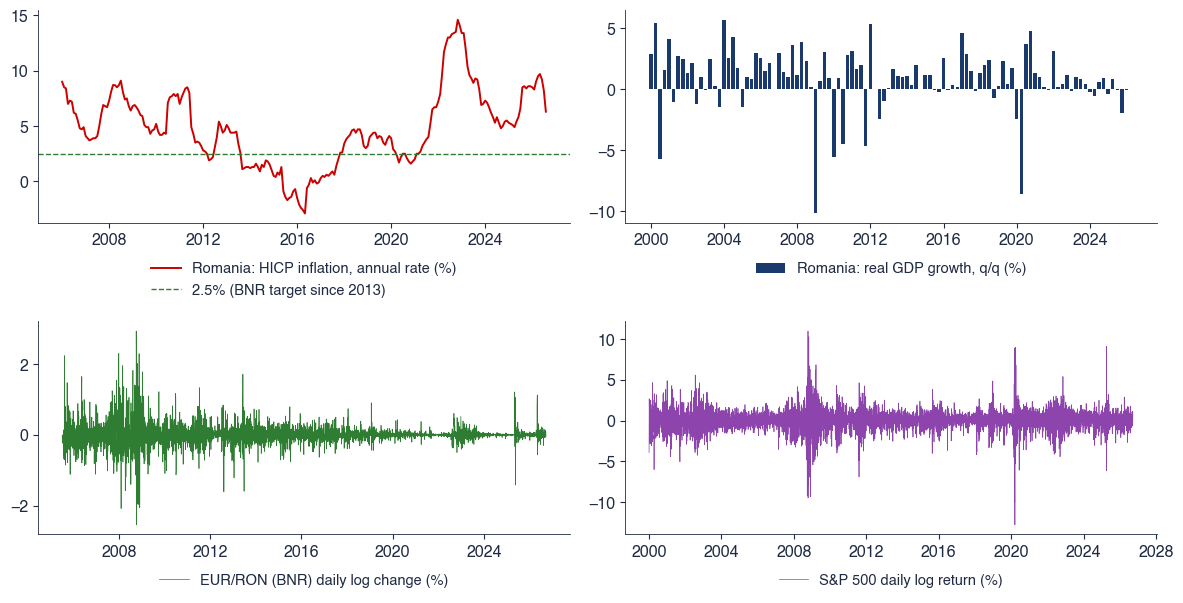

{'infl_first': '2006-01-01', 'infl_last': '2026-08-01', 'infl_n': 248, 'infl_max': 14.6, 'infl_max_d': '2022-11-01', 'infl_min': -2.9, 'infl_min_d': '2016-05-01', 'infl_last_v': 6.3, 'gdp_first': '2000-01-01', 'gdp_last': '2026-04-01', 'gdp_n': 106, 'gdp_min': -10.191377828463999, 'gdp_min_d': '2009-01-01', 'eur_first': '2005-07-05', 'eur_n': 5352, 'sp_n': 6714, 'sp_first': '2000-01-04', 'bet_n': 6670, 'last_daily': '2026-09-18'}


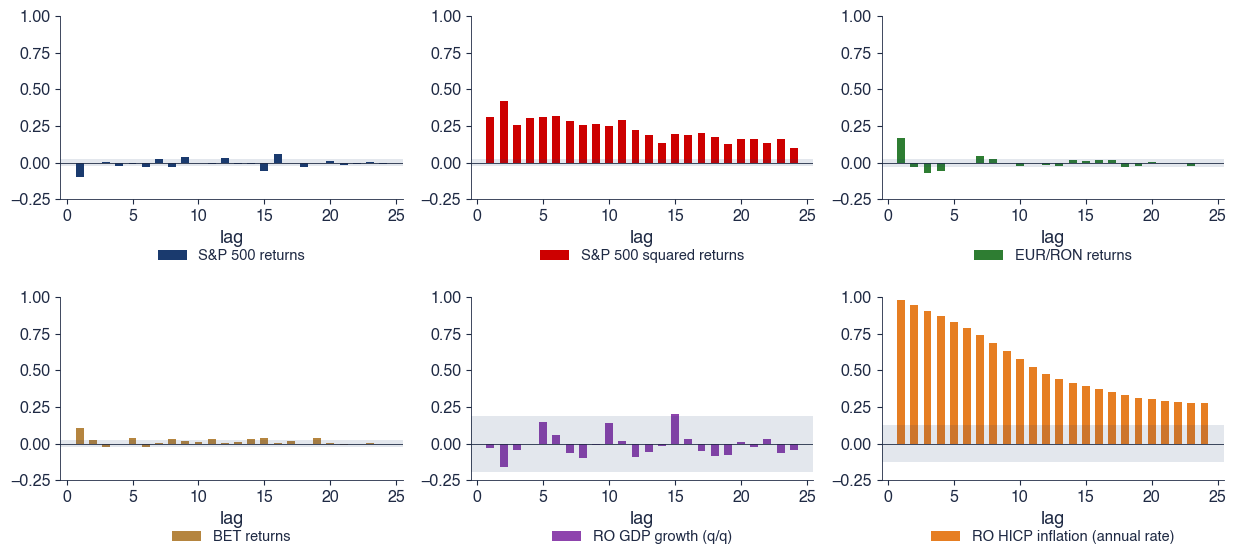

                                      T     r1     r5    r12   band  n_out  \
S&P 500 returns                  6714.0 -0.099 -0.011  0.034  0.024   10.0   
S&P 500 squared returns          6714.0  0.313  0.312  0.224  0.024   24.0   
EUR/RON returns                  5352.0  0.170 -0.004 -0.014  0.027    6.0   
BET returns                      6670.0  0.109  0.039  0.002  0.024    7.0   
RO GDP growth (q/q)               106.0 -0.032  0.150 -0.088  0.190    1.0   
RO HICP inflation (annual rate)   248.0  0.979  0.826  0.474  0.124   24.0   

                                 ratio_bartlett  ratio_andrews  
S&P 500 returns                           0.763          0.787  
S&P 500 squared returns                   4.141          5.662  
EUR/RON returns                           1.121          1.121  
BET returns                               1.250          1.212  
RO GDP growth (q/q)                       0.726          1.000  
RO HICP inflation (annual rate)           4.772         26.968 

In [6]:
def fig_data_dashboard(save_it=True):
    """Four series of the chapter: Romanian HICP inflation and GDP growth, EUR/RON and S&P 500 daily returns."""
    infl, gdp, d = ro_inflation(), ro_gdp_growth(), daily_series()
    fig, ax = plt.subplots(2, 2, figsize=(12, 6.2))
    ax[0, 0].plot(infl.index, infl, color=st.IDAred, label='Romania: HICP inflation, annual rate (%)')
    ax[0, 0].axhline(TARGET, color=st.Forest, ls='--', lw=1, label='2.5% (BNR target since 2013)')
    ax[0, 1].bar(gdp.index, gdp, width=70, color=st.MainBlue, label='Romania: real GDP growth, q/q (%)')
    e = d['EUR/RON returns']
    ax[1, 0].plot(e.index, e, color=st.Forest, lw=0.5, label='EUR/RON (BNR) daily log change (%)')
    s = d['S&P 500 returns']
    ax[1, 1].plot(s.index, s, color=st.Purple, lw=0.5, label='S&P 500 daily log return (%)')
    for a in ax.flat:
        a.legend(loc='upper center', bbox_to_anchor=(0.5, -0.12), frameon=False, fontsize=10.5)
    plt.tight_layout()
    save('ats_ch0_data_dashboard', save_it)
    out = {'infl_first': str(infl.index[0].date()), 'infl_last': str(infl.index[-1].date()), 'infl_n': len(infl),
           'infl_max': float(infl.max()), 'infl_max_d': str(infl.idxmax().date()), 'infl_min': float(infl.min()),
           'infl_min_d': str(infl.idxmin().date()), 'infl_last_v': float(infl.iloc[-1]),
           'gdp_first': str(gdp.index[0].date()), 'gdp_last': str(gdp.index[-1].date()), 'gdp_n': len(gdp),
           'gdp_min': float(gdp.min()), 'gdp_min_d': str(gdp.idxmin().date()),
           'eur_first': str(e.index[0].date()), 'eur_n': len(e), 'sp_n': len(s), 'sp_first': str(s.index[0].date()),
           'bet_n': len(d['BET returns']), 'last_daily': str(s.index[-1].date())}
    NUM['dash'] = out
    return out


def fig_acf_panel(save_it=True, K=24):
    """Sample ACF of six series of the chapter, with the +/- 1.96/sqrt(T) band of the i.i.d. hypothesis."""
    d = daily_series()
    ser = {'S&P 500 returns': d['S&P 500 returns'], 'S&P 500 squared returns': d['S&P 500 squared returns'],
           'EUR/RON returns': d['EUR/RON returns'], 'BET returns': d['BET returns'],
           'RO GDP growth (q/q)': ro_gdp_growth(), 'RO HICP inflation (annual rate)': ro_inflation()}
    cols = [st.MainBlue, st.IDAred, st.Forest, st.Amber, st.Purple, st.Orange]
    fig, ax = plt.subplots(2, 3, figsize=(12.5, 5.8))
    out = {}
    for a, (name, x), c in zip(ax.flat, ser.items(), cols):
        g = acov_all(x.values)
        r = g[1:K + 1] / g[0]
        band = 1.96 / np.sqrt(len(x))
        a.bar(np.arange(1, K + 1), r, color=c, width=0.6, label=name)
        a.axhspan(-band, band, color=st.MainBlue, alpha=0.12, lw=0)
        a.axhline(0, color=st.DarkText, lw=0.6)
        a.set_ylim(min(-0.25, r.min() - 0.05), 1.0)
        a.set_xlabel('lag')
        a.legend(loc='upper center', bbox_to_anchor=(0.5, -0.2), frameon=False, fontsize=10.5)
        T = len(x)
        out[name] = {'T': T, 'r1': float(r[0]), 'r5': float(r[4]), 'r12': float(r[11]), 'band': float(band),
                     'n_out': int((np.abs(r) > band).sum()), 'ratio_bartlett': float(lrv(x.values, nw_rule(T)) / g[0]),
                     'ratio_andrews': float(lrv(x.values, andrews_bw(x.values)) / g[0])}
    plt.tight_layout()
    save('ats_ch0_acf_panel', save_it)
    NUM['acf'] = out
    return out


print(fig_data_dashboard(save_it=False))
acf = fig_acf_panel(save_it=False)
print(pd.DataFrame(acf).T.round(3))

## 2. The long-run variance and the naive test

- AR(1): theory against simulation; the kernels; a negative truncated estimate.

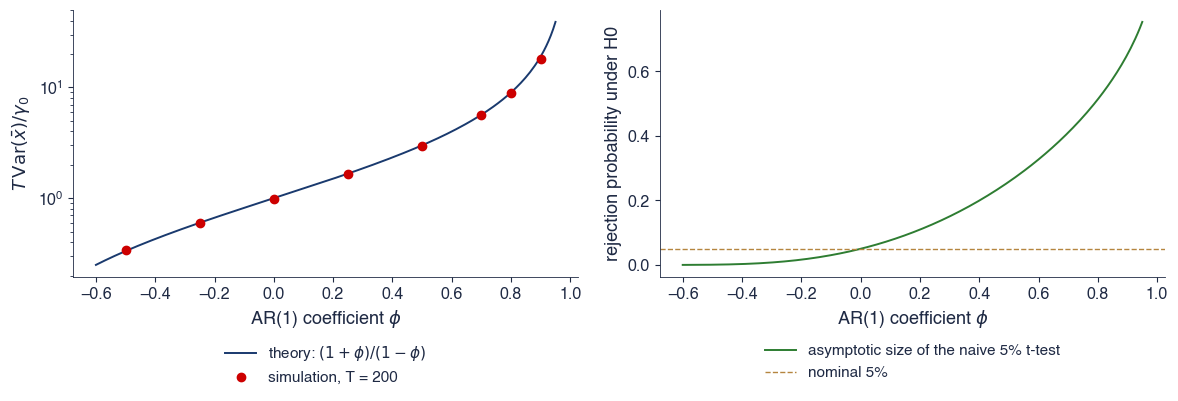

{'T': 200, 'reps': 20000, 'sim': {'-0.5': 0.3382670062672804, '-0.25': 0.596259962585125, '0.0': 0.9931832202036855, '0.25': 1.6525141421111917, '0.5': 2.9781423432772414, '0.7': 5.6038644431616, '0.8': 8.81129254749417, '0.9': 18.108549355508824}, 'f05': 3.0, 'f09': 19.000000000000004, 'fm05': 0.3333333333333333, 'size03': np.float64(0.15036404182488172), 'size05': np.float64(0.2577998945409883), 'size09': np.float64(0.6529593400365596), 'sizem05': np.float64(0.0006867383888435885), 'sim05': 2.9781423432772414, 'sim09': 18.108549355508824}


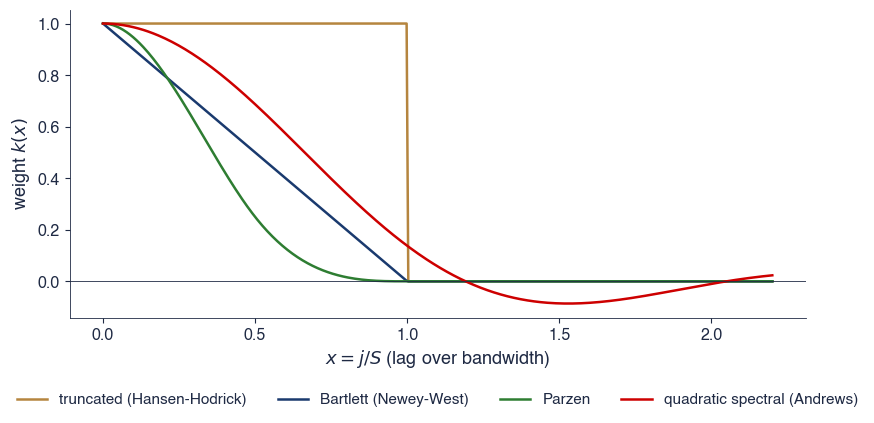

{'qs_min': -0.08617087088978208}
{'g0': 1.6, 'g1': -1.3, 'g2': 1.0, 'trunc_S2': 1.0, 'trunc_S1': -1.0, 'bart_S2': 0.30000000000000004, 'bart_S3': 0.5333333333333332}


In [7]:
def fig_lrv_ar1(save_it=True, T=200, reps=20000):
    """Variance inflation of the sample mean under AR(1): T Var(mean) / gamma_0 against phi, theory and simulation;
    asymptotic size of the naive 5% t-test."""
    rng = np.random.default_rng(SEED)
    phis = np.array([-0.5, -0.25, 0.0, 0.25, 0.5, 0.7, 0.8, 0.9])
    sim = []
    for p in phis:
        e = rng.standard_normal((reps, T + 200))
        x = np.zeros_like(e)
        for t in range(1, e.shape[1]):
            x[:, t] = p * x[:, t - 1] + e[:, t]
        x = x[:, 200:]
        sim.append(T * x.mean(axis=1).var() / (1 / (1 - p ** 2)))
    grid = np.linspace(-0.6, 0.95, 200)
    theo = (1 + grid) / (1 - grid)
    size = 2 * (1 - stats.norm.cdf(1.96 / np.sqrt(theo)))
    fig, ax = plt.subplots(1, 2, figsize=(12, 4.3))
    ax[0].plot(grid, theo, color=st.MainBlue, label=r'theory: $(1+\phi)/(1-\phi)$')
    ax[0].plot(phis, sim, 'o', color=st.IDAred, label=f'simulation, T = {T}')
    ax[0].set_yscale('log')
    ax[0].set_xlabel(r'AR(1) coefficient $\phi$')
    ax[0].set_ylabel(r'$T\,\mathrm{Var}(\bar{x}) / \gamma_0$')
    ax[1].plot(grid, size, color=st.Forest, label='asymptotic size of the naive 5% t-test')
    ax[1].axhline(0.05, color=st.Amber, ls='--', lw=1, label='nominal 5%')
    ax[1].set_xlabel(r'AR(1) coefficient $\phi$')
    ax[1].set_ylabel('rejection probability under H0')
    for a in ax:
        st.legend_outside_bottom(a, ncol=1, y=-0.2)
    plt.tight_layout()
    save('ats_ch0_lrv_ar1', save_it)
    f = lambda p: (1 + p) / (1 - p)
    sz = lambda p: 2 * (1 - stats.norm.cdf(1.96 / np.sqrt(f(p))))
    out = {'T': T, 'reps': reps, 'sim': dict(zip([str(p) for p in phis], [float(s) for s in sim])),
           'f05': f(0.5), 'f09': f(0.9), 'fm05': f(-0.5), 'size03': sz(0.3), 'size05': sz(0.5), 'size09': sz(0.9),
           'sizem05': sz(-0.5), 'sim05': float(sim[list(phis).index(0.5)]), 'sim09': float(sim[list(phis).index(0.9)])}
    NUM['lrv'] = out
    return out


def fig_kernels(save_it=True):
    """The kernels k(x) of Newey-West (Bartlett), Parzen and quadratic spectral, with the truncated kernel."""
    x = np.linspace(0, 2.2, 400)
    fig, ax = plt.subplots(figsize=(9.5, 4))
    for kind, c, lab in (('truncated', st.Amber, 'truncated (Hansen-Hodrick)'), ('bartlett', st.MainBlue, 'Bartlett (Newey-West)'),
                         ('parzen', st.Forest, 'Parzen'), ('qs', st.IDAred, 'quadratic spectral (Andrews)')):
        ax.plot(x, kernel(x, kind), color=c, label=lab, lw=1.8)
    ax.axhline(0, color=st.DarkText, lw=0.6)
    ax.set_xlabel(r'$x = j / S$ (lag over bandwidth)')
    ax.set_ylabel(r'weight $k(x)$')
    st.legend_outside_bottom(ax, ncol=4, y=-0.2)
    save('ats_ch0_kernels', save_it)
    out = {'qs_min': float(kernel(np.linspace(0, 5, 5001), 'qs').min())}
    NUM['kern'] = out
    return out


def truncated_negative_example():
    """A sample whose truncated-kernel long-run variance is negative while the Bartlett estimate is positive."""
    x = np.array([1.0, -1.0, 1.0, -1.0, 1.0, -1.0, 1.0, -1.0, 2.0, -2.0])
    g = acov_all(x)
    return {'g0': float(g[0]), 'g1': float(g[1]), 'g2': float(g[2]), 'trunc_S2': float(g[0] + 2 * g[1] + 2 * g[2]),
            'trunc_S1': float(g[0] + 2 * g[1]), 'bart_S2': float(lrv(x, 2.0)), 'bart_S3': float(lrv(x, 3.0))}


print(fig_lrv_ar1(save_it=False))
print(fig_kernels(save_it=False))
print(truncated_negative_example())

## 3. HAC in practice: bandwidth and fixed-b

- HAC standard error against the bandwidth; fixed-b critical values by simulation.

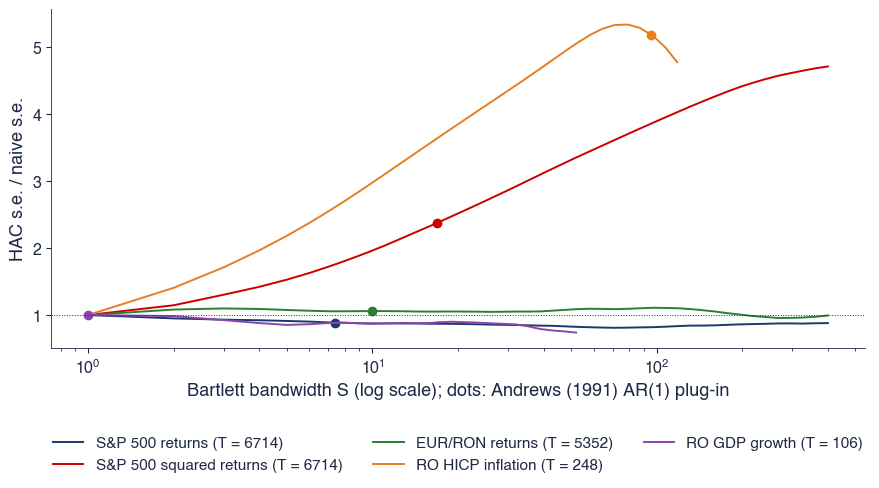

                              T   S_and  r_and  S_nw   r_nw  r_max  S_max
S&P 500 returns          6714.0   7.363  0.887  11.0  0.874  1.000    1.0
S&P 500 squared returns  6714.0  16.934  2.379  11.0  2.035  4.717  400.0
EUR/RON returns          5352.0   9.935  1.059  10.0  1.059  1.108   97.0
RO HICP inflation         248.0  95.756  5.193   5.0  2.185  5.343   79.0
RO GDP growth             106.0   1.000  1.000   5.0  0.852  1.000    1.0


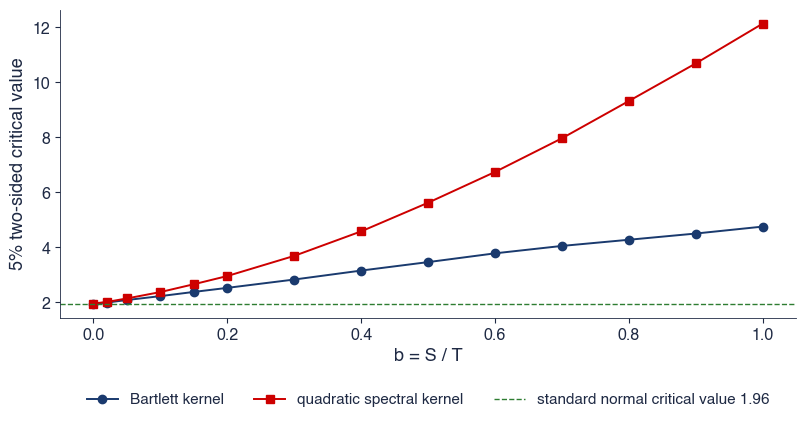

{0.02: 1.996, 0.05: 2.088, 0.1: 2.23, 0.15: 2.382, 0.2: 2.53, 0.3: 2.832, 0.4: 3.158, 0.5: 3.466, 0.6: 3.784, 0.7: 4.053, 0.8: 4.278, 0.9: 4.504, 1.0: 4.756}


In [8]:
def fig_hac_bandwidth(save_it=True):
    """HAC standard error of the mean relative to the naive one, as a function of the Bartlett bandwidth."""
    d = daily_series()
    ser = {'S&P 500 returns': d['S&P 500 returns'], 'S&P 500 squared returns': d['S&P 500 squared returns'],
           'EUR/RON returns': d['EUR/RON returns'], 'RO HICP inflation': ro_inflation(),
           'RO GDP growth': ro_gdp_growth()}
    cols = [st.MainBlue, st.IDAred, st.Forest, st.Orange, st.Purple]
    Ss = np.unique(np.round(np.geomspace(1, 400, 60)))
    fig, ax = plt.subplots(figsize=(10.5, 4.4))
    out = {}
    for (name, x), c in zip(ser.items(), cols):
        x = x.values
        T = len(x)
        g0 = acov_all(x)[0]
        Sv = Ss[Ss <= T / 2]
        ratio = np.sqrt([lrv(x, S) / g0 for S in Sv])
        ax.plot(Sv, ratio, color=c, label=f'{name} (T = {T})')
        Sa = float(andrews_bw(x))
        ax.plot([Sa], [np.sqrt(lrv(x, Sa) / g0)], 'o', color=c, ms=6, label='_a')
        out[name] = {'T': T, 'S_and': Sa, 'r_and': float(np.sqrt(lrv(x, Sa) / g0)), 'S_nw': nw_rule(T),
                     'r_nw': float(np.sqrt(lrv(x, nw_rule(T)) / g0)), 'r_max': float(ratio.max()),
                     'S_max': float(Sv[np.argmax(ratio)])}
    ax.axhline(1, color=st.DarkText, lw=0.7, ls=':')
    ax.set_xscale('log')
    ax.set_xlabel('Bartlett bandwidth S (log scale); dots: Andrews (1991) AR(1) plug-in')
    ax.set_ylabel('HAC s.e. / naive s.e.')
    st.legend_outside_bottom(ax, ncol=3, y=-0.22)
    save('ats_ch0_hac_bandwidth', save_it)
    NUM['bw'] = out
    return out


def fig_fixed_b(save_it=True, cvtab=None, cvqs=None):
    """Fixed-b critical values (two-sided 5%) of the Bartlett and QS t-tests against b = S/T (Kiefer and Vogelsang 2005)."""
    cvtab = cvtab or fixed_b_table()
    cvqs = cvqs or fixed_b_table(kind='qs')
    bs = sorted(cvtab)
    fig, ax = plt.subplots(figsize=(9.5, 4))
    ax.plot([0] + bs, [1.96] + [cvtab[b] for b in bs], 'o-', color=st.MainBlue, label='Bartlett kernel')
    ax.plot([0] + bs, [1.96] + [cvqs[b] for b in bs], 's-', color=st.IDAred, label='quadratic spectral kernel')
    ax.axhline(1.96, color=st.Forest, ls='--', lw=1, label='standard normal critical value 1.96')
    ax.set_xlabel('b = S / T')
    ax.set_ylabel('5% two-sided critical value')
    st.legend_outside_bottom(ax, ncol=3, y=-0.2)
    save('ats_ch0_fixed_b', save_it)
    out = {'bart': {str(b): v for b, v in cvtab.items()}, 'qs': {str(b): v for b, v in cvqs.items()}}
    NUM['fixedb'] = out
    return cvtab, cvqs


print(pd.DataFrame(fig_hac_bandwidth(save_it=False)).T.round(3))
cvtab, cvqs = fig_fixed_b(save_it=False)
print({b: round(v, 3) for b, v in cvtab.items()})

## 4. Monte Carlo of size

- Seven tests of $H_0: \mu = 0$ under AR(1) dependence; reduce `reps` to go faster.

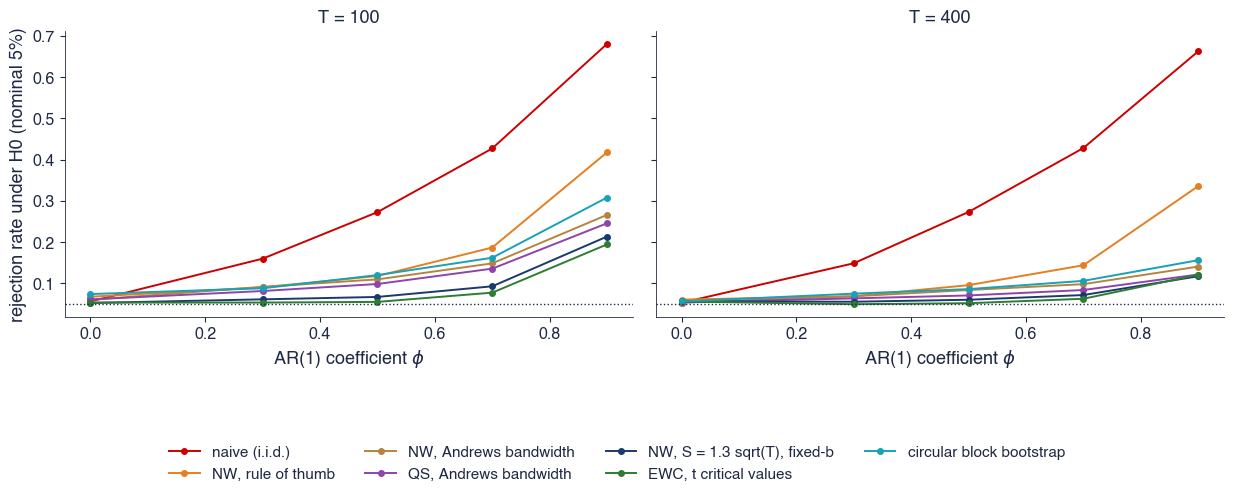

T = 100
     naive     nw  andrews     qs   llsw    ewc    cbb
0.0  0.056  0.068    0.060  0.061  0.052  0.053  0.074
0.3  0.160  0.090    0.091  0.081  0.061  0.053  0.088
0.5  0.273  0.118    0.110  0.098  0.067  0.055  0.120
0.7  0.427  0.187    0.148  0.136  0.093  0.077  0.162
0.9  0.681  0.418    0.266  0.246  0.213  0.194  0.308
T = 400
     naive     nw  andrews     qs   llsw    ewc    cbb
0.0  0.053  0.061    0.053  0.054  0.056  0.056  0.056
0.3  0.149  0.069    0.069  0.064  0.055  0.049  0.075
0.5  0.273  0.096    0.084  0.071  0.060  0.052  0.086
0.7  0.428  0.144    0.098  0.084  0.072  0.063  0.106
0.9  0.662  0.336    0.141  0.121  0.117  0.121  0.156


In [9]:
def fig_mc_size(save_it=True, cvtab=None, reps=5000, breps=1000):
    """Monte Carlo size of the 5% t-test for a mean under AR(1) dependence, T = 100 and T = 400."""
    cvtab = cvtab or fixed_b_table()
    phis = (0.0, 0.3, 0.5, 0.7, 0.9)
    res = {T: {p: mc_size(p, T, cvtab, reps=reps, breps=breps) for p in phis} for T in (100, 400)}
    lab = {'naive': 'naive (i.i.d.)', 'nw': 'NW, rule of thumb', 'andrews': 'NW, Andrews bandwidth',
           'qs': 'QS, Andrews bandwidth', 'llsw': 'NW, S = 1.3 sqrt(T), fixed-b', 'ewc': 'EWC, t critical values',
           'cbb': 'circular block bootstrap'}
    cols = dict(zip(lab, [st.IDAred, st.Orange, st.Amber, st.Purple, st.MainBlue, st.Forest, st.Teal]))
    fig, ax = plt.subplots(1, 2, figsize=(12.5, 4.4), sharey=True)
    for a, T in zip(ax, (100, 400)):
        for k in lab:
            a.plot(phis, [res[T][p][k] for p in phis], 'o-', color=cols[k], label=lab[k], ms=4)
        a.axhline(0.05, color=st.DarkText, ls=':', lw=1)
        a.set_title(f'T = {T}')
        a.set_xlabel(r'AR(1) coefficient $\phi$')
    ax[0].set_ylabel('rejection rate under H0 (nominal 5%)')
    st.fig_legend_bottom(fig, ncol=4, y=0.0)
    plt.tight_layout(rect=(0, 0.1, 1, 1))
    save('ats_ch0_mc_size', save_it)
    out = {str(T): {str(p): res[T][p] for p in phis} for T in res}
    NUM['mc'] = {'res': out, 'reps': reps, 'breps': breps}
    return out


mc = fig_mc_size(save_it=False, cvtab=cvtab)
for T_, r in mc.items():
    print('T =', T_)
    print(pd.DataFrame(r).T.round(3))

## 5. Block bootstrap

- Three bootstraps of one mean; the block length; the six series by method.

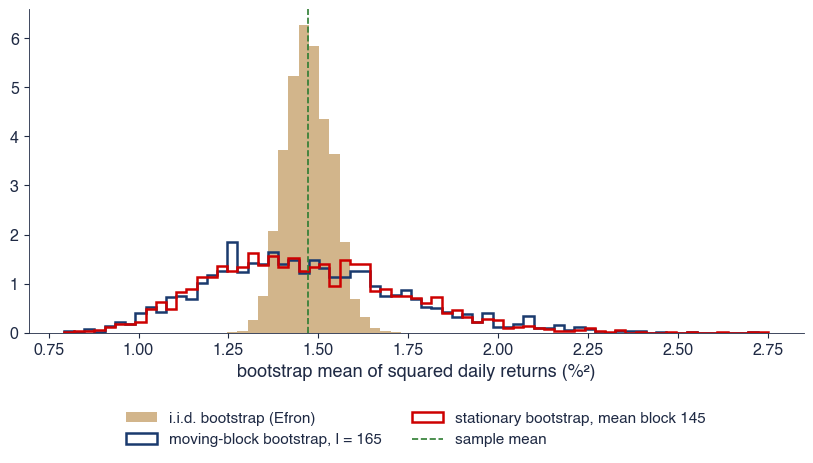

{'T': 6714, 'mean': 1.4718326406844875, 'b_sb': 144.56797877581445, 'b_cb': 165.48902432182257, 'se_naive': 0.06383375657499352, 'se_iid': 0.06256550387060773, 'se_mbb': 0.2758464153402376, 'se_cbb': 0.2675409790681457, 'se_sb': 0.26861521202370026, 'se_and': 0.15188639183901476, 'se_qs': 0.13034169167249673, 'mbb_bias': -0.005785074229690768, 'cbb_bias': -0.0026615494095563186}


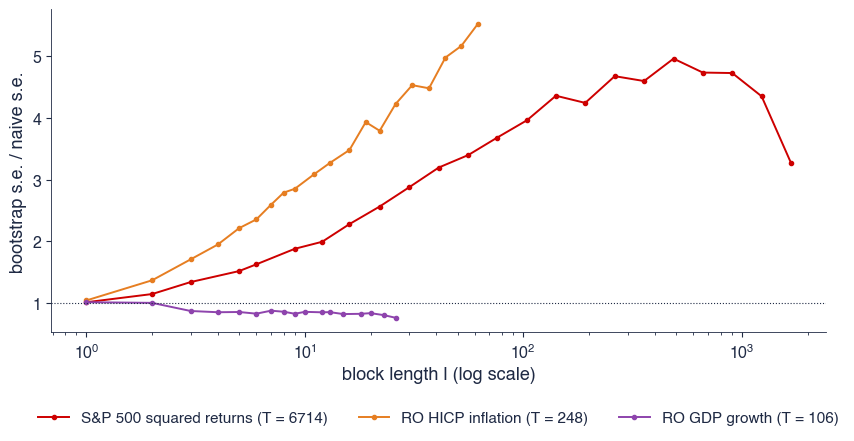

{'S&P 500 squared returns': {'T': 6714, 'b_sb': 144.56797877581445, 'b_cb': 165.48902432182257, 'r_pw': 4.319101467936935}, 'RO HICP inflation': {'T': 248, 'b_sb': 22.11474003984138, 'b_cb': 25.315057893970863, 'r_pw': 4.213294442785269}, 'RO GDP growth': {'T': 106, 'b_sb': 0.7936127132897961, 'b_cb': 0.9084597759742233, 'r_pw': 0.9607080653452236}}


           T    mean    rho1  se_naive  se_andrews  se_llsw  se_ewc   se_sb  \
sp    6714.0  0.0247 -0.0986    0.0148      0.0131   0.0122  0.0119  0.0129   
sq    6714.0  1.4718  0.3132    0.0638      0.1519   0.2522  0.2194  0.2916   
bet   6670.0  0.0639  0.1089    0.0171      0.0188   0.0234  0.0221  0.0187   
eur   5352.0  0.0071  0.1697    0.0038      0.0040   0.0042  0.0041  0.0039   
gdp    106.0  0.8290 -0.0322    0.2395      0.2395   0.2108  0.2259  0.2397   
infl   248.0  4.7992  0.9796    0.2177      1.1305   0.8453  0.8103  0.9572   

      t_naive   t_ewc  
sp     1.6698  2.0693  
sq    23.0573  6.7078  
bet    3.7334  2.8888  
eur    1.8612  1.7344  
gdp    3.4615  3.6705  
infl  22.0454  5.9227  


In [10]:
def fig_bootstrap(save_it=True, B=1999):
    """Bootstrap distributions of the mean of S&P 500 squared returns: i.i.d., moving-block, stationary."""
    rng = np.random.default_rng(SEED)
    x = daily_series()['S&P 500 squared returns'].values
    T = len(x)
    b_sb, b_cb = politis_white(x)
    m_iid = iid_means(x, B, rng)
    m_mbb = mbb_means(x, b_cb, B, rng)
    m_cbb = mbb_means(x, b_cb, B, rng, circular=True)
    idx = sb_indices(T, b_sb, B, rng)
    m_sb = x[idx].mean(axis=1)
    fig, ax = plt.subplots(figsize=(10, 4.2))
    bins = np.linspace(min(m_iid.min(), m_sb.min()), max(m_iid.max(), m_sb.max()), 70)
    ax.hist(m_iid, bins=bins, color=st.Amber, alpha=0.6, density=True, label='i.i.d. bootstrap (Efron)')
    ax.hist(m_mbb, bins=bins, histtype='step', color=st.MainBlue, lw=1.8, density=True,
            label=f'moving-block bootstrap, l = {int(round(b_cb))}')
    ax.hist(m_sb, bins=bins, histtype='step', color=st.IDAred, lw=1.8, density=True,
            label=f'stationary bootstrap, mean block {b_sb:.0f}')
    ax.axvline(x.mean(), color=st.Forest, ls='--', lw=1.2, label='sample mean')
    ax.set_xlabel('bootstrap mean of squared daily returns (%²)')
    st.legend_outside_bottom(ax, ncol=2, y=-0.2)
    save('ats_ch0_bootstrap', save_it)
    g0 = acov_all(x)[0]
    out = {'T': T, 'mean': float(x.mean()), 'b_sb': b_sb, 'b_cb': b_cb, 'se_naive': float(np.sqrt(g0 / T)),
           'se_iid': float(m_iid.std()), 'se_mbb': float(m_mbb.std()), 'se_cbb': float(m_cbb.std()),
           'se_sb': float(m_sb.std()), 'se_and': float(np.sqrt(lrv(x, andrews_bw(x)) / T)),
           'se_qs': float(np.sqrt(lrv(x, andrews_bw(x, 'qs'), 'qs') / T)),
           'mbb_bias': float(m_mbb.mean() - x.mean()), 'cbb_bias': float(m_cbb.mean() - x.mean())}
    NUM['boot'] = out
    return out


def fig_block_length(save_it=True, B=999):
    """Bootstrap standard error of the mean against the block length (circular block bootstrap), three series."""
    rng = np.random.default_rng(SEED + 1)
    d = daily_series()
    ser = {'S&P 500 squared returns': d['S&P 500 squared returns'], 'RO HICP inflation': ro_inflation(),
           'RO GDP growth': ro_gdp_growth()}
    cols = [st.IDAred, st.Orange, st.Purple]
    fig, ax = plt.subplots(figsize=(10, 4.2))
    out = {}
    for (name, x), c in zip(ser.items(), cols):
        x = x.values
        T = len(x)
        se0 = np.sqrt(acov_all(x)[0] / T)
        ls = np.unique(np.round(np.geomspace(1, T / 4, 25))).astype(int)
        r = [mbb_means(x, l, B, rng, circular=True).std() / se0 for l in ls]
        ax.plot(ls, r, 'o-', ms=3, color=c, label=f'{name} (T = {T})')
        b_sb, b_cb = politis_white(x)
        out[name] = {'T': T, 'b_sb': b_sb, 'b_cb': b_cb,
                     'r_pw': float(mbb_means(x, b_cb, B, rng, circular=True).std() / se0)}
    ax.axhline(1, color=st.DarkText, ls=':', lw=0.8)
    ax.set_xscale('log')
    ax.set_xlabel('block length l (log scale)')
    ax.set_ylabel('bootstrap s.e. / naive s.e.')
    st.legend_outside_bottom(ax, ncol=3, y=-0.2)
    save('ats_ch0_block_length', save_it)
    NUM['blk'] = out
    return out


def real_data_table(cvtab=None, B=1999):
    """Mean, standard errors and confidence intervals by method for six series of the chapter."""
    cvtab = cvtab or fixed_b_table()
    rng = np.random.default_rng(SEED + 2)
    d = daily_series()
    ser = {'sp': d['S&P 500 returns'], 'sq': d['S&P 500 squared returns'], 'bet': d['BET returns'],
           'eur': d['EUR/RON returns'], 'gdp': ro_gdp_growth(), 'infl': ro_inflation()}
    out = {}
    for k, x in ser.items():
        x = x.values
        r = mean_inference(x, cvtab)
        b_sb, b_cb = politis_white(x)
        idx = sb_indices(len(x), b_sb, B, rng)
        r['se_sb'] = float(x[idx].mean(axis=1).std())
        r['b_sb'] = b_sb
        r['ratio_and'] = r['se_andrews'] / r['se_naive']
        r['ratio_sb'] = r['se_sb'] / r['se_naive']
        out[k] = r
    NUM['tab'] = out
    return out


print(fig_bootstrap(save_it=False))
print(fig_block_length(save_it=False))
tab = pd.DataFrame(real_data_table(cvtab=cvtab)).T
print(tab[['T', 'mean', 'rho1', 'se_naive', 'se_andrews', 'se_llsw', 'se_ewc', 'se_sb', 't_naive', 't_ewc']].round(4))

## 6. Overlapping observations: the term spread and future growth

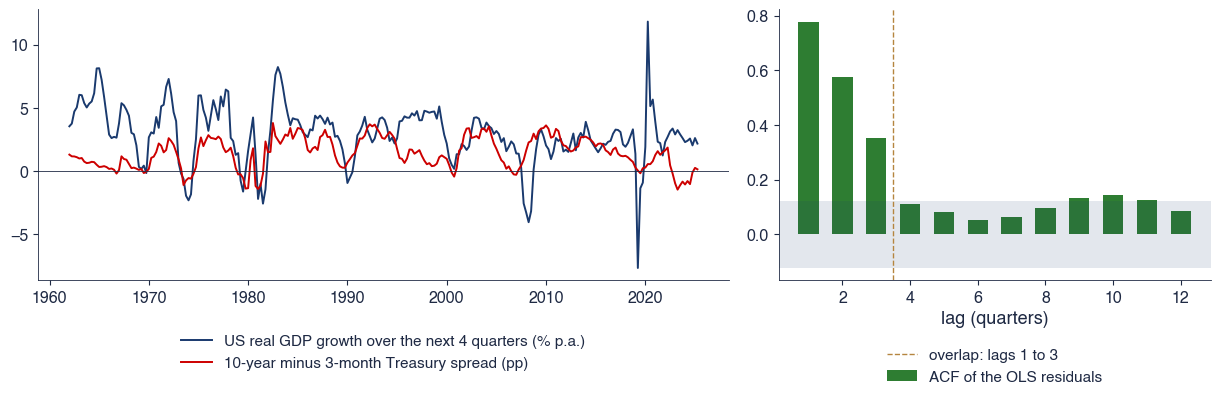

{'T': 254, 'first': '1962-01-01', 'last': '2025-04-01', 'b0': 2.1868958953162596, 'b1': 0.5173694776152612, 'se_classic': 0.10971522916942246, 'se_white': 0.10411910227364683, 'se_nw': 0.16686740221568788, 'se_hh': 0.19836822445294314, 'se_and': 0.2302275916409368, 'S_and': 13.913990441066513, 'se_ll': 0.2537983960300555, 'S_ll': np.float64(20.718590685661997), 'cv_ll': 2.1773874811859284, 'rho1': 0.7785454907850929, 'rho3': 0.35379092214587426, 'rho4': 0.11263007673767342, 'rho8': 0.09492762657763501, 'r2': 0.08108535298262332, 'sub': {'early': {'b': 1.1173096525167727, 'se': 0.24296619208423698, 't': 4.598621902628325, 'n': 108}, 'late': {'b': 0.14937468095805803, 'se': 0.16614611478873104, 't': 0.8990561178514507, 'n': 146}}, 't_classic': 4.71556666774435, 't_nw': 3.1004826032260313, 't_and': 2.247208833345011, 't_ll': 2.0385057025892035}


In [11]:
def fig_term_spread(save_it=True, cvtab=None, h=H_TS):
    """Annualised US real GDP growth over the next four quarters on the 10-year minus 3-month Treasury spread:
    OLS, White, Newey-West (h lags), Andrews and fixed-b standard errors; residual autocorrelation."""
    cvtab = cvtab or fixed_b_table()
    d = term_spread_data(h)
    y, X = d['growth'].values, np.column_stack([np.ones(len(d)), d['spread'].values])
    T = len(y)
    b, se_ols, u = ols_hac(y, X)
    s2 = u @ u / (T - 2)
    se_classic = np.sqrt(np.diag(s2 * np.linalg.inv(X.T @ X)))
    _, se_nw, _ = ols_hac(y, X, S=h)            # Bartlett with h - 1 = 3 lags: S = h
    _, se_hh, _ = ols_hac(y, X, S=h - 1 + 1e-9, kind='truncated')   # Hansen-Hodrick: truncated kernel, h - 1 lags
    Sa = float(andrews_bw(u * (X[:, 1] - X[:, 1].mean())))
    _, se_and, _ = ols_hac(y, X, S=Sa)
    S_ll = llsw_bw(T)
    _, se_ll, _ = ols_hac(y, X, S=S_ll)
    g = acov_all(u)
    rho = g[1:13] / g[0]
    sub = {}
    for lab, (a, z) in {'early': ('1962-01-01', '1988-12-31'), 'late': ('1989-01-01', '2030-01-01')}.items():
        dd = d.loc[a:z]
        bb, ss, _ = ols_hac(dd['growth'].values, np.column_stack([np.ones(len(dd)), dd['spread'].values]), S=h)
        sub[lab] = {'b': float(bb[1]), 'se': float(ss[1]), 't': float(bb[1] / ss[1]), 'n': len(dd)}
    fig, ax = plt.subplots(1, 2, figsize=(12.5, 4.3), gridspec_kw={'width_ratios': [1.6, 1]})
    ax[0].plot(d.index, d['growth'], color=st.MainBlue, label='US real GDP growth over the next 4 quarters (% p.a.)')
    ax[0].plot(d.index, d['spread'], color=st.IDAred, label='10-year minus 3-month Treasury spread (pp)')
    ax[0].axhline(0, color=st.DarkText, lw=0.6)
    st.legend_outside_bottom(ax[0], ncol=1, y=-0.15)
    ax[1].bar(np.arange(1, 13), rho, color=st.Forest, width=0.6, label='ACF of the OLS residuals')
    ax[1].axhspan(-1.96 / np.sqrt(T), 1.96 / np.sqrt(T), color=st.MainBlue, alpha=0.12, lw=0)
    ax[1].axvline(h - 0.5, color=st.Amber, ls='--', lw=1, label=f'overlap: lags 1 to {h - 1}')
    ax[1].set_xlabel('lag (quarters)')
    st.legend_outside_bottom(ax[1], ncol=1, y=-0.2)
    plt.tight_layout()
    save('ats_ch0_term_spread', save_it)
    out = {'T': T, 'first': str(d.index[0].date()), 'last': str(d.index[-1].date()), 'b0': float(b[0]), 'b1': float(b[1]),
           'se_classic': float(se_classic[1]), 'se_white': float(se_ols[1]), 'se_nw': float(se_nw[1]),
           'se_hh': float(se_hh[1]), 'se_and': float(se_and[1]), 'S_and': Sa, 'se_ll': float(se_ll[1]), 'S_ll': S_ll,
           'cv_ll': fixed_b_cv(S_ll / T, cvtab), 'rho1': float(rho[0]), 'rho3': float(rho[2]), 'rho4': float(rho[3]),
           'rho8': float(rho[7]), 'r2': float(1 - u @ u / ((y - y.mean()) @ (y - y.mean()))), 'sub': sub}
    out['t_classic'] = out['b1'] / out['se_classic']
    out['t_nw'] = out['b1'] / out['se_nw']
    out['t_and'] = out['b1'] / out['se_and']
    out['t_ll'] = out['b1'] / out['se_ll']
    NUM['ts'] = out
    return out


print(fig_term_spread(save_it=False, cvtab=cvtab))

## 7. Data snooping and the Reality Check

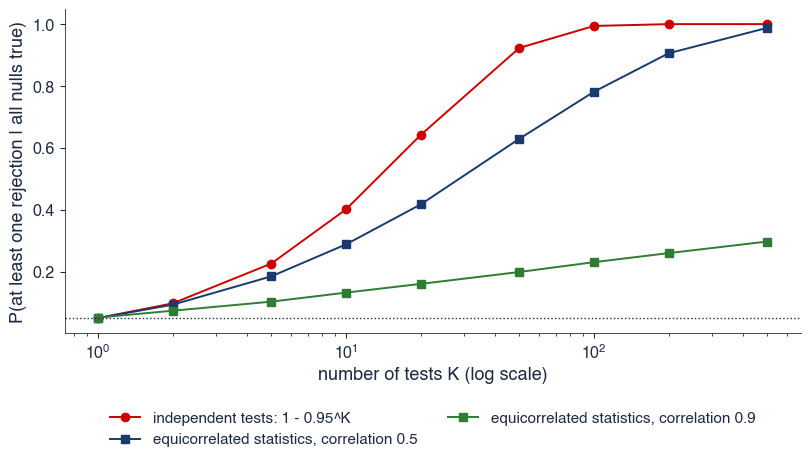

{'indep': {'1': 0.050000000000000044, '2': 0.09750000000000003, '5': 0.22621906250000023, '10': 0.4012630607616213, '20': 0.6415140775914581, '50': 0.9230550247232868, '100': 0.994079470779666, '200': 0.9999649473337512, '500': 0.9999999999927255}, '0.5': {'1': 0.04985, '2': 0.0932, '5': 0.18485, '10': 0.28815, '20': 0.4172, '50': 0.6294, '100': 0.78145, '200': 0.9058, '500': 0.98795}, '0.9': {'1': 0.0516, '2': 0.07375, '5': 0.1031, '10': 0.13225, '20': 0.16045, '50': 0.19895, '100': 0.2307, '200': 0.2599, '500': 0.29735}, 'bonf20': 0.0025}


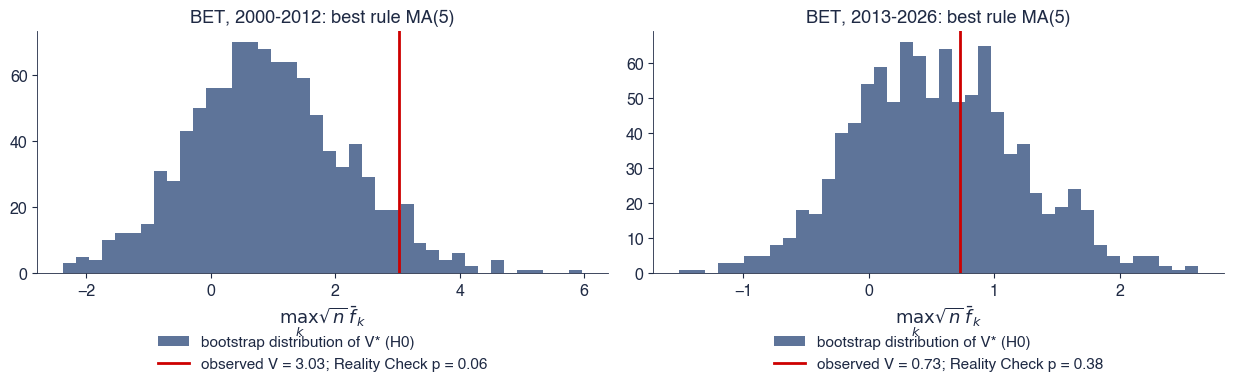

{'2000-2012': {'V': 3.0254569123833495, 'p_rc': 0.057057057057057055, 'best': 0, 'best_mean': 0.0553015894565522, 't_best': 2.5096522176775093, 'p_naive': 0.006042505900134887, 'n': 2993, 'K': 50, 'n_sig': 3, 'first': '2001-01-03', 'last': '2012-12-28', 'best_n': 5}, '2013-2026': {'V': 0.7263028910175611, 'p_rc': 0.3833833833833834, 'best': 0, 'best_mean': 0.012887762553920785, 't_best': 0.9738979999436641, 'p_naive': 0.16505359345858595, 'n': 3176, 'K': 50, 'n_sig': 0, 'first': '2014-01-03', 'last': '2026-09-18', 'best_n': 5}}


In [12]:
def fig_snooping(save_it=True, reps=20000):
    """Probability that the best of K tests rejects at 5% when every null is true: independent tests and
    equicorrelated test statistics (correlation 0.5 and 0.9)."""
    rng = np.random.default_rng(SEED)
    Ks = np.array([1, 2, 5, 10, 20, 50, 100, 200, 500])
    fig, ax = plt.subplots(figsize=(9.5, 4.2))
    ax.plot(Ks, 1 - 0.95 ** Ks, 'o-', color=st.IDAred, label='independent tests: 1 - 0.95^K')
    out = {'indep': {str(k): float(1 - 0.95 ** k) for k in Ks}}
    for rho, c in ((0.5, st.MainBlue), (0.9, st.Forest)):
        z0 = rng.standard_normal((reps, 1))
        fw = []
        for K in Ks:
            z = np.sqrt(rho) * z0 + np.sqrt(1 - rho) * rng.standard_normal((reps, K))
            fw.append(float((np.abs(z).max(axis=1) > 1.96).mean()))
        ax.plot(Ks, fw, 's-', color=c, label=f'equicorrelated statistics, correlation {rho}')
        out[str(rho)] = dict(zip([str(k) for k in Ks], fw))
    ax.axhline(0.05, color=st.DarkText, ls=':', lw=1)
    ax.set_xscale('log')
    ax.set_xlabel('number of tests K (log scale)')
    ax.set_ylabel('P(at least one rejection | all nulls true)')
    st.legend_outside_bottom(ax, ncol=2, y=-0.2)
    save('ats_ch0_snooping', save_it)
    out['bonf20'] = 0.05 / 20
    NUM['snoop'] = out
    return out


def fig_reality_check(save_it=True, B=999):
    """Reality Check of White (2000) for 50 moving-average rules on the BET index, two subsamples."""
    p = load_close('bet')
    out = {}
    fig, ax = plt.subplots(1, 2, figsize=(12.5, 4.2))
    for a, (lab, (s, e)) in zip(ax, {'2000-2012': ('2000-01-01', '2012-12-31'),
                                     '2013-2026': ('2013-01-01', '2026-12-31')}.items()):
        f = ma_rule_returns(p.loc[s:e])
        rc = reality_check(f.values, B=B)
        rc['first'], rc['last'] = str(f.index[0].date()), str(f.index[-1].date())
        rc['best_n'] = int(f.columns[rc['best']])
        a.hist(rc.pop('Vs'), bins=40, color=st.MainBlue, alpha=0.7, label='bootstrap distribution of V* (H0)')
        a.axvline(rc['V'], color=st.IDAred, lw=2, label=f"observed V = {rc['V']:.2f}; Reality Check p = {rc['p_rc']:.2f}")
        a.set_title(f'BET, {lab}: best rule MA({rc["best_n"]})')
        a.set_xlabel(r'$\max_k \sqrt{n}\,\bar f_k$')
        st.legend_outside_bottom(a, ncol=1, y=-0.2)
        out[lab] = rc
    plt.tight_layout()
    save('ats_ch0_reality_check', save_it)
    NUM['rc'] = out
    return out


print(fig_snooping(save_it=False))
print(fig_reality_check(save_it=False))

## 8. AI mini-case: mean inflation against the target

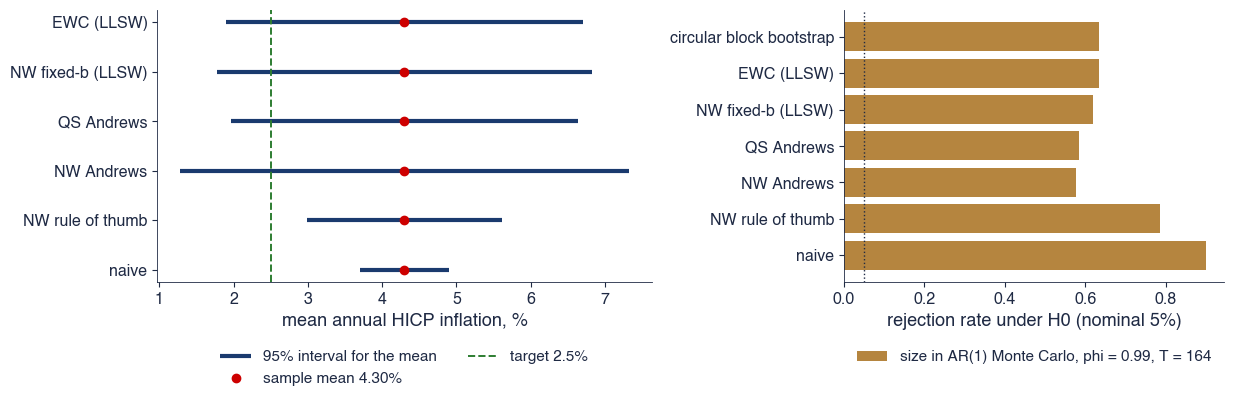

{'T': 164, 'mean': np.float64(4.301219512195122), 'rho1': 0.9878578593268416, 'S_nw': 5, 'S_and': 118.12329258095691, 'S_qs': 164.0, 'S_ll': np.float64(16.648123017325407), 'nu': 12, 'se_naive': 0.30404641184672687, 't_naive': np.float64(5.924159740135782), 'cv_naive': 1.96, 'lo_naive': np.float64(3.705288544975538), 'hi_naive': np.float64(4.897150479414707), 'se_nw': 0.6686212725093582, 't_nw': np.float64(2.6939309086518963), 'cv_nw': 1.96, 'lo_nw': np.float64(2.9907218180767803), 'hi_nw': np.float64(5.611717206313465), 'se_andrews': 1.5433305518194653, 't_andrews': np.float64(1.1670989795877664), 'cv_andrews': 1.96, 'lo_andrews': np.float64(1.2762916306289704), 'hi_andrews': np.float64(7.326147393761275), 'se_qs': 1.1910825888372174, 't_qs': np.float64(1.5122540863883713), 'cv_qs': 1.96, 'lo_qs': np.float64(1.9666976380741765), 'hi_qs': np.float64(6.635741386316068), 'se_llsw': 1.1296624409575196, 't_llsw': np.float64(1.5944758778280532), 'cv_llsw': 2.2343777748526663, 'lo_llsw': np.

In [13]:
def fig_ai_minicase(save_it=True, cvtab=None, reps=5000):
    """Mean Romanian HICP inflation since 2013 against 2.5%: confidence intervals by method, and the size of each
    test in a Monte Carlo calibrated to the AR(1) fitted to the series."""
    cvtab = cvtab or fixed_b_table()
    x = ro_inflation(TARGET_START).values
    T = len(x)
    r = mean_inference(x, cvtab, mu0=TARGET)
    phi = float(ar1_coef(x))
    mc = mc_size(phi, T, cvtab, reps=reps, breps=500)
    lab = {'naive': 'naive', 'nw': 'NW rule of thumb', 'andrews': 'NW Andrews', 'qs': 'QS Andrews',
           'llsw': 'NW fixed-b (LLSW)', 'ewc': 'EWC (LLSW)'}
    fig, ax = plt.subplots(1, 2, figsize=(12.5, 4.3), gridspec_kw={'width_ratios': [1.3, 1]})
    for i, k in enumerate(lab):
        ax[0].plot([r[f'lo_{k}'], r[f'hi_{k}']], [i, i], color=st.MainBlue, lw=3, solid_capstyle='butt',
                   label='95% interval for the mean' if i == 0 else '_')
    ax[0].plot([r['mean']] * len(lab), range(len(lab)), 'o', color=st.IDAred, label=f"sample mean {r['mean']:.2f}%")
    ax[0].axvline(TARGET, color=st.Forest, ls='--', label='target 2.5%')
    ax[0].set_yticks(range(len(lab)))
    ax[0].set_yticklabels(list(lab.values()))
    ax[0].set_xlabel('mean annual HICP inflation, %')
    st.legend_outside_bottom(ax[0], ncol=2, y=-0.2)
    keys = list(lab) + ['cbb']
    ax[1].barh(range(len(keys)), [mc[k] for k in keys], color=st.Amber, label=f'size in AR(1) Monte Carlo, phi = {phi:.2f}, T = {T}')
    ax[1].axvline(0.05, color=st.DarkText, ls=':', lw=1)
    ax[1].set_yticks(range(len(keys)))
    ax[1].set_yticklabels(list(lab.values()) + ['circular block bootstrap'])
    ax[1].set_xlabel('rejection rate under H0 (nominal 5%)')
    st.legend_outside_bottom(ax[1], ncol=1, y=-0.2)
    plt.tight_layout()
    save('ats_ch0_ai_minicase', save_it)
    out = dict(r, phi=phi, mc=mc, first=TARGET_START, last=str(ro_inflation().index[-1].date()))
    NUM['ai'] = out
    return out


print(fig_ai_minicase(save_it=False, cvtab=cvtab))

## Exercises

1. Replace the AR(1) DGP of `mc_size` with an MA(1) with $\theta = 0.8$ and compare the sizes.
2. Compute the Reality Check on the S&P 500 for the same 50 moving-average rules.
3. Use `statsmodels` (`OLS(...).fit(cov_type='HAC', cov_kwds={'maxlags': L})`) to reproduce the Newey–West standard error of the term-spread slope with $L = 3$.